In [4]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data (2).csv


In [6]:
import pandas as pd
df = pd.read_csv('cleaned_data (2).csv')
df.head()

,Price,Area,Location,City,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,30000000,3340,JP Nagar Phase 1,Bangalore,4,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,Bangalore,2,0,0,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,Bangalore,2,0,0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,Bangalore,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,Bangalore,3,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0


In [11]:
# ============================================
# PHASE 3: ML MODELLING
# Real Estate Price Intelligence Platform
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import shap

plt.rcParams['figure.figsize'] = (12, 6)

# Load cleaned data
df = pd.read_csv('cleaned_data (2).csv')

print(f"✅ Data loaded: {df.shape}")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")

✅ Data loaded: (32963, 41)
   Rows: 32,963
   Columns: 41


In [8]:
import os

# Create the outputs directory if it doesn't exist
if not os.path.exists('outputs'):
    os.makedirs('outputs')
    print("Created 'outputs/' directory")
else:
    print("'outputs/' directory already exists")

'outputs/' directory already exists


In [9]:
# ============================================
# Step 2: Feature Preparation
# ============================================

# Check all columns
print("ALL COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

ALL COLUMNS:
   1. Price
   2. Area
   3. Location
   4. City
   5. No. of Bedrooms
   6. Resale
   7. MaintenanceStaff
   8. Gymnasium
   9. SwimmingPool
  10. LandscapedGardens
  11. JoggingTrack
  12. RainWaterHarvesting
  13. IndoorGames
  14. ShoppingMall
  15. Intercom
  16. SportsFacility
  17. ATM
  18. ClubHouse
  19. School
  20. 24X7Security
  21. PowerBackup
  22. CarParking
  23. StaffQuarter
  24. Cafeteria
  25. MultipurposeRoom
  26. Hospital
  27. WashingMachine
  28. Gasconnection
  29. AC
  30. Wifi
  31. Children'splayarea
  32. LiftAvailable
  33. BED
  34. VaastuCompliant
  35. Microwave
  36. GolfCourse
  37. TV
  38. DiningTable
  39. Sofa
  40. Wardrobe
  41. Refrigerator


In [13]:
# ============================================
# Step 2: Feature Preparation
# ============================================

# This cell's original content caused a NameError because 'feature_cols' was not defined.
# The definition and selection of features (feature_cols) and the creation of X and y
# are handled in a later cell (specifically, cell hQ_rxbHt0kly).
# This cell is now a placeholder to prevent errors and ensure a clearer flow.
print("Feature preparation steps for X and y are handled in a subsequent cell.")

Feature preparation steps for X and y are handled in a subsequent cell.


In [14]:
print(df.columns.tolist())

['Price', 'Area', 'Location', 'City', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'City_encoded', 'Location_encoded', 'is_new', 'area_per_bedroom', 'luxury_score', 'convenience_score', 'furnished_score', 'total_amenity_score']


In [15]:
df['is_new'] = df['Resale'].apply(lambda x: 0 if x == 1 else 1)

In [16]:
# Avoid division error
df['area_per_bedroom'] = df['Area'] / df['No. of Bedrooms'].replace(0, 1)

# Luxury features
luxury_cols = ['SwimmingPool', 'Gymnasium', 'GolfCourse']
df['luxury_score'] = df[luxury_cols].sum(axis=1)

# Convenience features
conv_cols = ['School', 'Hospital', 'ShoppingMall']
df['convenience_score'] = df[conv_cols].sum(axis=1)

# Furnishing features
furnish_cols = ['AC', 'TV', 'Wardrobe', 'Sofa', 'Refrigerator']
df['furnished_score'] = df[furnish_cols].sum(axis=1)

# Total amenities
amenity_cols = [
    'MaintenanceStaff','Gymnasium','SwimmingPool','LandscapedGardens',
    'JoggingTrack','RainWaterHarvesting','IndoorGames','ShoppingMall',
    'Intercom','SportsFacility','ATM','ClubHouse','School',
    '24X7Security','PowerBackup','CarParking','StaffQuarter',
    'Cafeteria','MultipurposeRoom','Hospital','WashingMachine',
    'Gasconnection','AC','Wifi',"Children'splayarea",
    'LiftAvailable','BED','VaastuCompliant','Microwave',
    'GolfCourse','TV','DiningTable','Sofa','Wardrobe','Refrigerator'
]

df['total_amenity_score'] = df[amenity_cols].sum(axis=1)

In [17]:
feature_cols = [
    'Area',
    'No. of Bedrooms',
    'City_encoded',
    'Location_encoded',
    'is_new',
    'area_per_bedroom',
    'luxury_score',
    'convenience_score',
    'furnished_score',
    'total_amenity_score'
]

In [18]:
X = df[feature_cols].copy()
y = np.log1p(df['Price'])
y_raw = df['Price']

In [42]:
# Example transformations (adjust based on your data)

from sklearn.preprocessing import LabelEncoder

# Encodings
city = LabelEncoder()
df['City_encoded'] = city.fit_transform(df['City'])

loc = LabelEncoder()
df['Location_encoded'] = loc.fit_transform(df['Location'])

# New property flag
df['is_new'] = df['Resale'].apply(lambda x: 0 if x == 1 else 1)
# Derived features
df['area_per_bedroom'] = df['Area'] / df['No. of Bedrooms'].replace(0, 1) # Added .replace(0,1) to avoid division by zero

# Example scores (customize logic)
df['luxury_score'] = df[['SwimmingPool','Gymnasium','GolfCourse']].sum(axis=1)
df['convenience_score'] = df[['School','Hospital','ShoppingMall']].sum(axis=1)
df['furnished_score'] = df[['AC','TV','Wardrobe','Sofa']].sum(axis=1)

# Define amenity_features here for total_amenity_score calculation
amenity_features = [col for col in df.columns
                    if col in [
    'MaintenanceStaff','Gymnasium','SwimmingPool',
    'LandscapedGardens','JoggingTrack',
    'RainWaterHarvesting','IndoorGames','ShoppingMall',
    'Intercom','SportsFacility','ATM','ClubHouse',
    'School','24X7Security','PowerBackup','CarParking',
    'LiftAvailable','WashingMachine','Gasconnection',
    'AC','Wifi','TV','Refrigerator','GolfCourse',
    'VaastuCompliant','Microwave','DiningTable',
    'Sofa','Wardrobe','StaffQuarter','Cafeteria',
    'MultipurposeRoom','Hospital','BED',
    "Children'splayarea"
]]

# Total amenities
df['total_amenity_score'] = df[amenity_features].sum(axis=1)

In [48]:
df['price_per_sqft'] = df['Price'] / df['Area']

In [20]:
# ============================================
# Step 2C: Define feature set
# ============================================

# Core features
core_features = [
    'Area',
    'No. of Bedrooms',
    'City_encoded',
    'Location_encoded',
    'is_new',
    'price_per_sqft',      # from feature engineering
    'area_per_bedroom',
    'luxury_score',
    'convenience_score',
    'furnished_score',
    'total_amenity_score'
]

# All amenity features (binary)
amenity_features = [col for col in df.columns
                    if col in [
    'MaintenanceStaff','Gymnasium','SwimmingPool',
    'LandscapedGardens','JoggingTrack',
    'RainWaterHarvesting','IndoorGames','ShoppingMall',
    'Intercom','SportsFacility','ATM','ClubHouse',
    'School','24X7Security','PowerBackup','CarParking',
    'LiftAvailable','WashingMachine','Gasconnection',
    'AC','Wifi','TV','Refrigerator','GolfCourse',
    'VaastuCompliant','Microwave','DiningTable',
    'Sofa','Wardrobe','StaffQuarter','Cafeteria',
    'MultipurposeRoom','Hospital','BED',
    "Children'splayarea"
]]

# Final feature list
# Note: Remove price_per_sqft to avoid data leakage
# (it's derived from Price which is our target)
feature_cols = [
    'Area',
    'No. of Bedrooms',
    'City_encoded',
    'Location_encoded',
    'is_new',
    'area_per_bedroom',
    'luxury_score',
    'convenience_score',
    'furnished_score',
    'total_amenity_score'
] + amenity_features

# Remove duplicates
feature_cols = list(dict.fromkeys(feature_cols))

# Target variable — use log transform
X = df[feature_cols].copy()
y = np.log1p(df['Price'])   # log transform
y_raw = df['Price']          # keep raw for reporting

print(f"✅ Feature set defined")
print(f"   Total features: {len(feature_cols)}")
print(f"   Target: log(Price)")
print(f"   Sample size: {len(X):,}")

✅ Feature set defined
   Total features: 45
   Target: log(Price)
   Sample size: 32,963


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Convert back from log
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")

MAE: 7,185,702
RMSE: 27,371,922


In [23]:
# ============================================
# Step 4: Train Models
# ============================================

# --- MODEL 1: Random Forest ---
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("✅ Random Forest trained")

# --- MODEL 2: XGBoost ---
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)
print("✅ XGBoost trained")

# --- MODEL 3: Gradient Boosting ---
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
print("✅ Gradient Boosting trained")

Training Random Forest...
✅ Random Forest trained
Training XGBoost...
✅ XGBoost trained
Training Gradient Boosting...
✅ Gradient Boosting trained


In [24]:
# ============================================
# Step 5: Model Evaluation
# ============================================

def evaluate_model(name, y_true_log, y_pred_log,
                   y_true_raw):
    # Convert predictions back from log scale
    y_pred_raw = np.expm1(y_pred_log)

    r2   = r2_score(y_true_log, y_pred_log)
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(
                   y_true_raw, y_pred_raw))
    mape = np.mean(np.abs(
           (y_true_raw - y_pred_raw) / y_true_raw
           )) * 100

    return {
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE (₹)': f"₹{mae/1e5:.2f}L",
        'RMSE (₹)': f"₹{rmse/1e5:.2f}L",
        'MAPE (%)': f"{mape:.2f}%"
    }

results = [
    evaluate_model("Random Forest",
                   y_test, rf_pred, y_test),
    evaluate_model("XGBoost",
                   y_test, xgb_pred, y_test),
    evaluate_model("Gradient Boosting",
                   y_test, gb_pred, y_test),
]

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("   MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)


   MODEL COMPARISON RESULTS
            Model  R² Score MAE (₹) RMSE (₹)     MAPE (%)
    Random Forest    0.4084 ₹88.36L ₹113.85L 54735273.18%
          XGBoost    0.4167 ₹88.20L ₹119.50L 54602698.56%
Gradient Boosting    0.4063 ₹85.97L ₹107.18L 53365246.11%


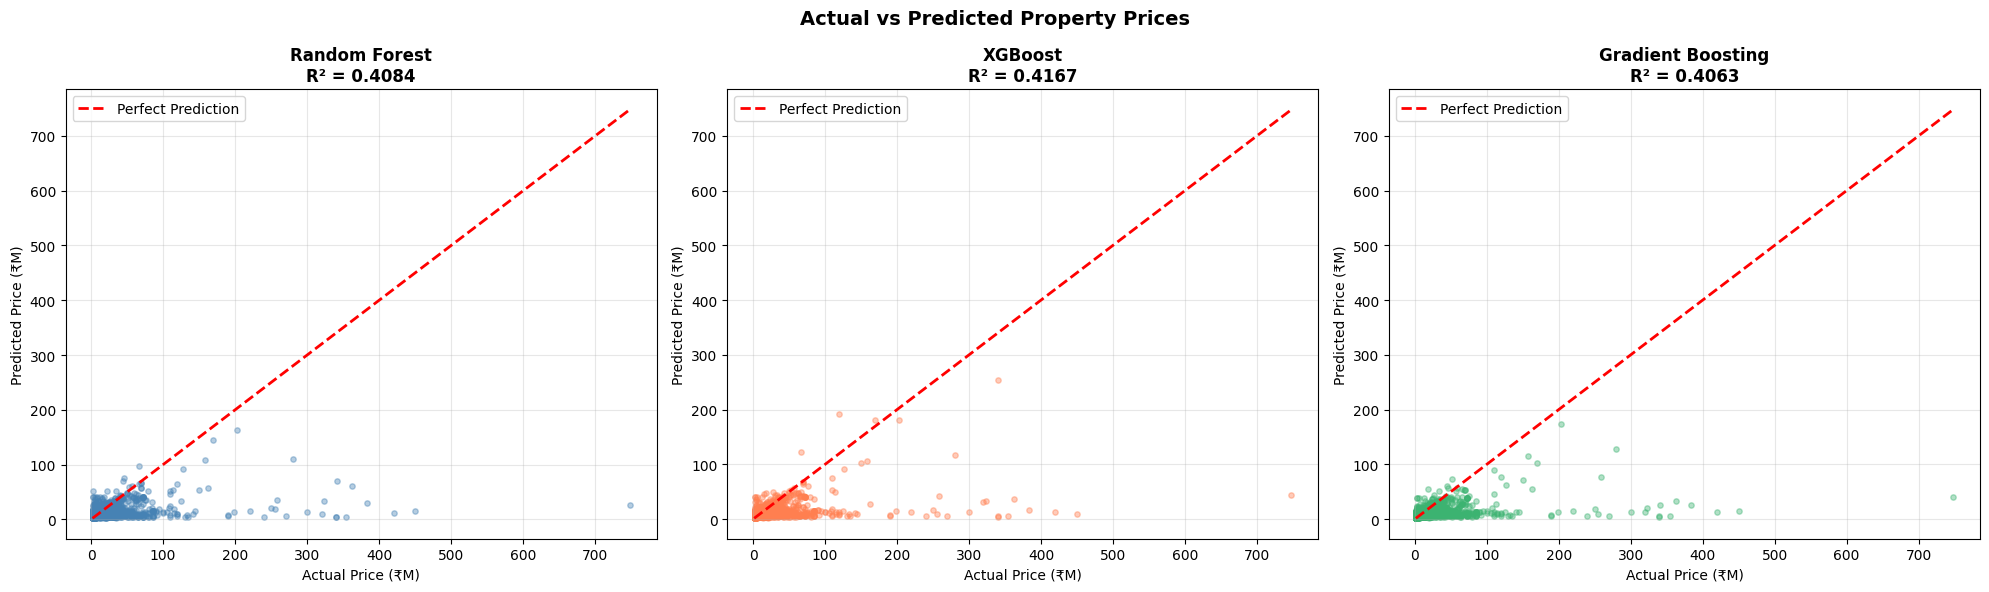

In [25]:
# ============================================
# Step 6: Actual vs Predicted Plot
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_info = [
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred),
    ("Gradient Boosting", gb_pred)
]

for i, (name, pred) in enumerate(models_info):
    # Convert back to raw prices
    actual = np.expm1(y_test) / 1e6
    predicted = np.expm1(pred) / 1e6

    axes[i].scatter(actual, predicted,
                    alpha=0.4, s=15,
                    color=['steelblue',
                           'coral',
                           'mediumseagreen'][i])

    # Perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val],
                 [min_val, max_val],
                 'r--', linewidth=2,
                 label='Perfect Prediction')

    r2 = r2_score(y_test, pred)
    axes[i].set_title(f'{name}\nR² = {r2:.4f}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Actual Price (₹M)')
    axes[i].set_ylabel('Predicted Price (₹M)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Property Prices',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()

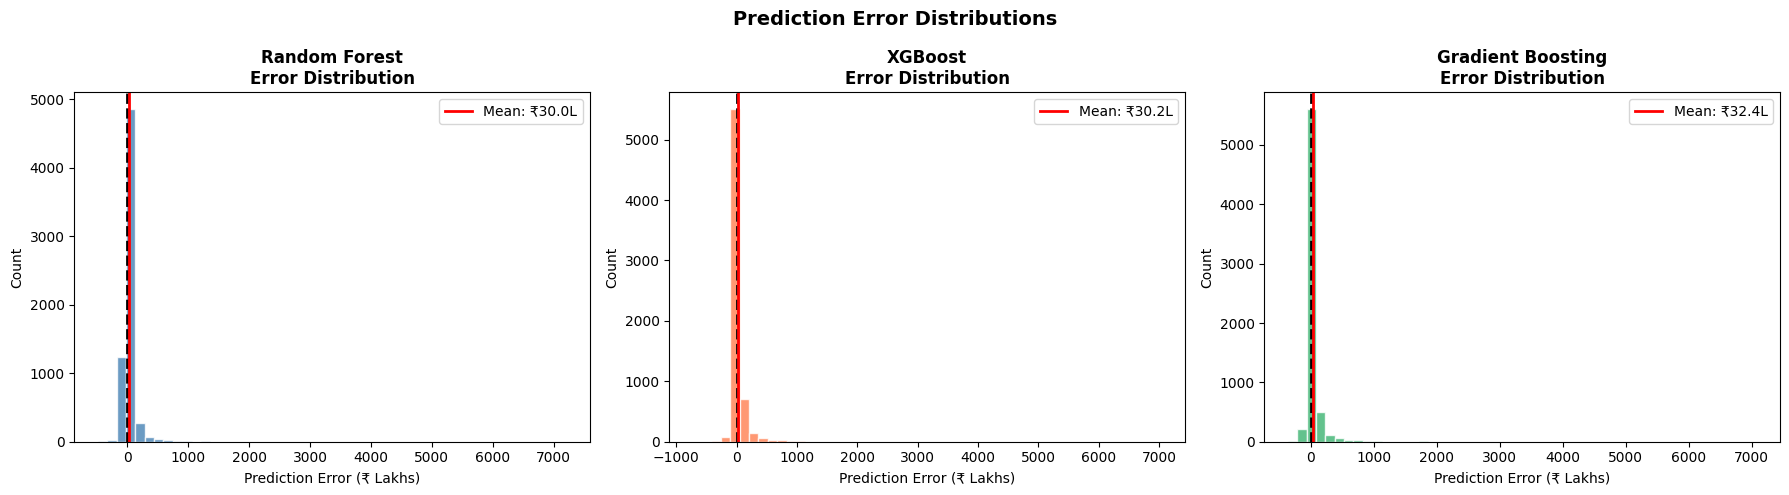

In [26]:
# ============================================
# Step 6B: Prediction Error Distribution
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(models_info):
    actual_raw = np.expm1(y_test)
    pred_raw = np.expm1(pred)
    errors = (actual_raw - pred_raw) / 1e5

    axes[i].hist(errors, bins=50,
                 color=['steelblue',
                        'coral',
                        'mediumseagreen'][i],
                 edgecolor='white', alpha=0.8)
    axes[i].axvline(0, color='black',
                    linewidth=2, linestyle='--')
    axes[i].axvline(errors.mean(),
                    color='red', linewidth=2,
                    label=f'Mean: ₹{errors.mean():.1f}L')
    axes[i].set_title(f'{name}\nError Distribution',
                      fontweight='bold')
    axes[i].set_xlabel('Prediction Error (₹ Lakhs)')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Prediction Error Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_02_error_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ============================================
# Step 7: SHAP Explainability
# Use best model (whichever has highest R²)
# ============================================

print("Computing SHAP values (takes 2-3 minutes)...")

# Use XGBoost for SHAP (fastest)
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

print("✅ SHAP values computed!")

Computing SHAP values (takes 2-3 minutes)...
✅ SHAP values computed!


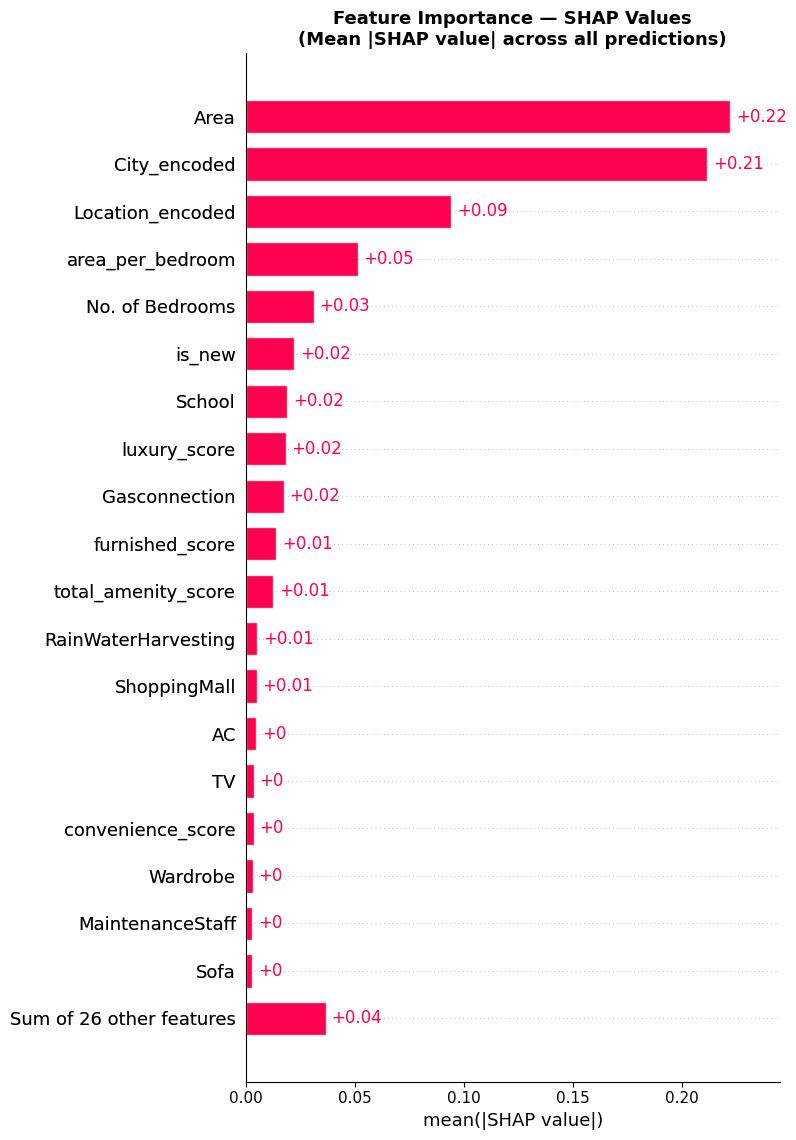

In [28]:
# ── SHAP Plot 1: Overall Feature Importance ──
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values, max_display=20,
               show=False)
plt.title('Feature Importance — SHAP Values\n'
          '(Mean |SHAP value| across all predictions)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_03_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

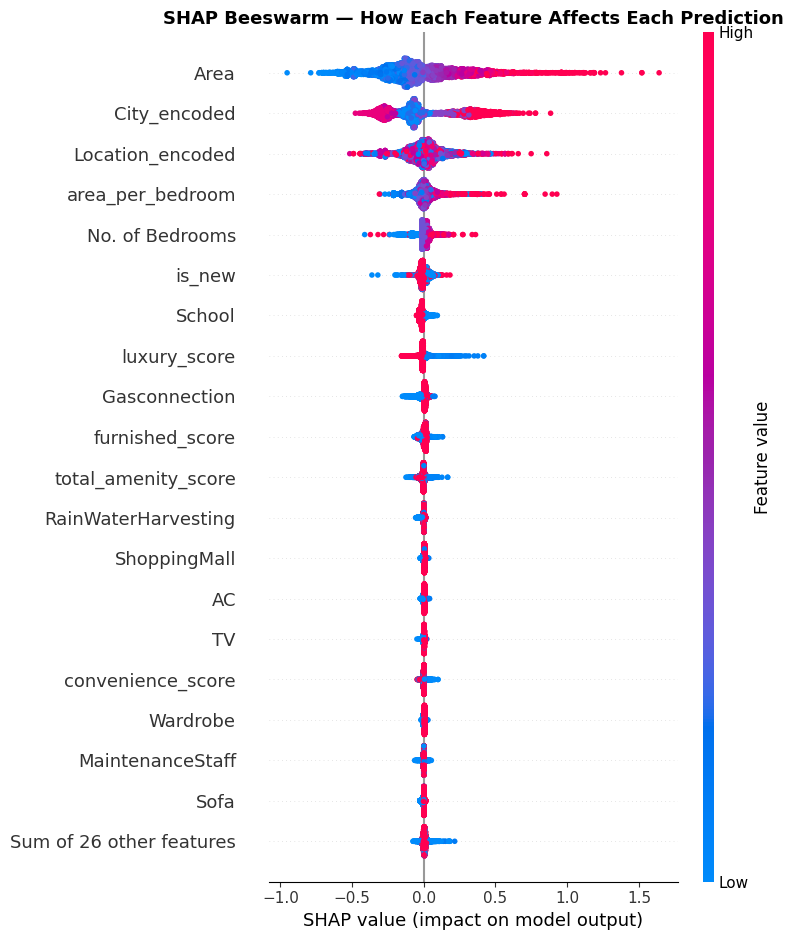

In [29]:
# ── SHAP Plot 2: Beeswarm ──────────────────
plt.figure(figsize=(12, 9))
shap.plots.beeswarm(shap_values, max_display=20,
                    show=False)
plt.title('SHAP Beeswarm — How Each Feature '
          'Affects Each Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_04_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

EXPLAINING ONE PROPERTY PREDICTION:
Actual Price:    ₹160.00L
Predicted Price: ₹132.20L


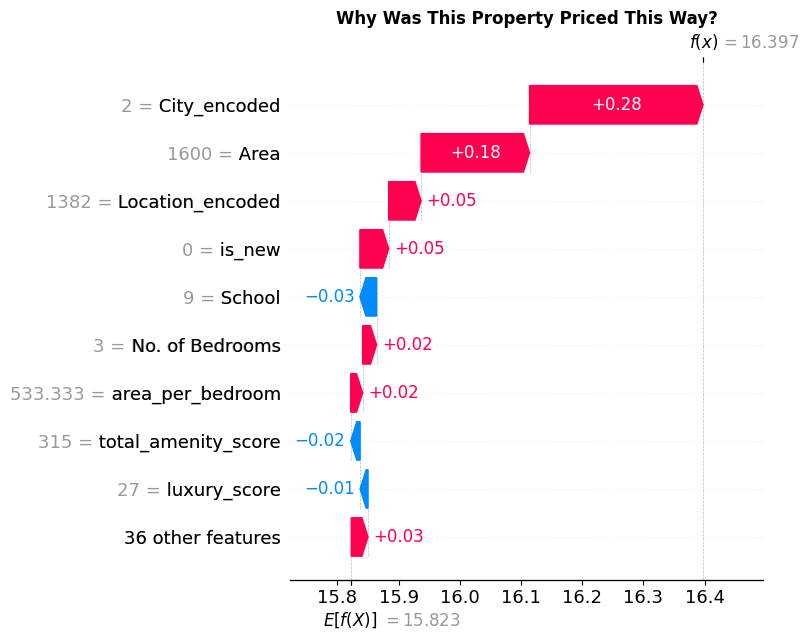

In [30]:
# ── SHAP Plot 3: Explain ONE specific house ─
print("EXPLAINING ONE PROPERTY PREDICTION:")
print(f"Actual Price:    ₹{np.expm1(y_test.iloc[0])/1e5:.2f}L")
print(f"Predicted Price: ₹{np.expm1(xgb_pred[0])/1e5:.2f}L")

shap.plots.waterfall(shap_values[0], show=False)
plt.title('Why Was This Property Priced This Way?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_05_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ============================================
# Step 8: Overvalued / Undervalued Detector
# ============================================

# Predict on ENTIRE dataset
X_full = df[feature_cols].copy()
df['predicted_price'] = np.expm1(
    xgb_model.predict(X_full))

# Calculate deviation
df['price_deviation_%'] = (
    (df['Price'] - df['predicted_price'])
    / df['predicted_price'] * 100
)

# Classify
def classify(dev):
    if dev > 20:
        return 'Overvalued'
    elif dev < -20:
        return 'Undervalued'
    else:
        return 'Fair Value'

df['valuation_status'] = \
    df['price_deviation_%'].apply(classify)

# Summary
print("VALUATION STATUS SUMMARY")
print("="*40)
print(df['valuation_status'].value_counts())
print()

total = len(df)
for status in ['Overvalued', 'Fair Value',
               'Undervalued']:
    count = (df['valuation_status']==status).sum()
    pct = count/total*100
    print(f"{status:<12}: {count:>5,} ({pct:.1f}%)")

VALUATION STATUS SUMMARY
valuation_status
Fair Value     14752
Undervalued     9467
Overvalued      8744
Name: count, dtype: int64

Overvalued  : 8,744 (26.5%)
Fair Value  : 14,752 (44.8%)
Undervalued : 9,467 (28.7%)


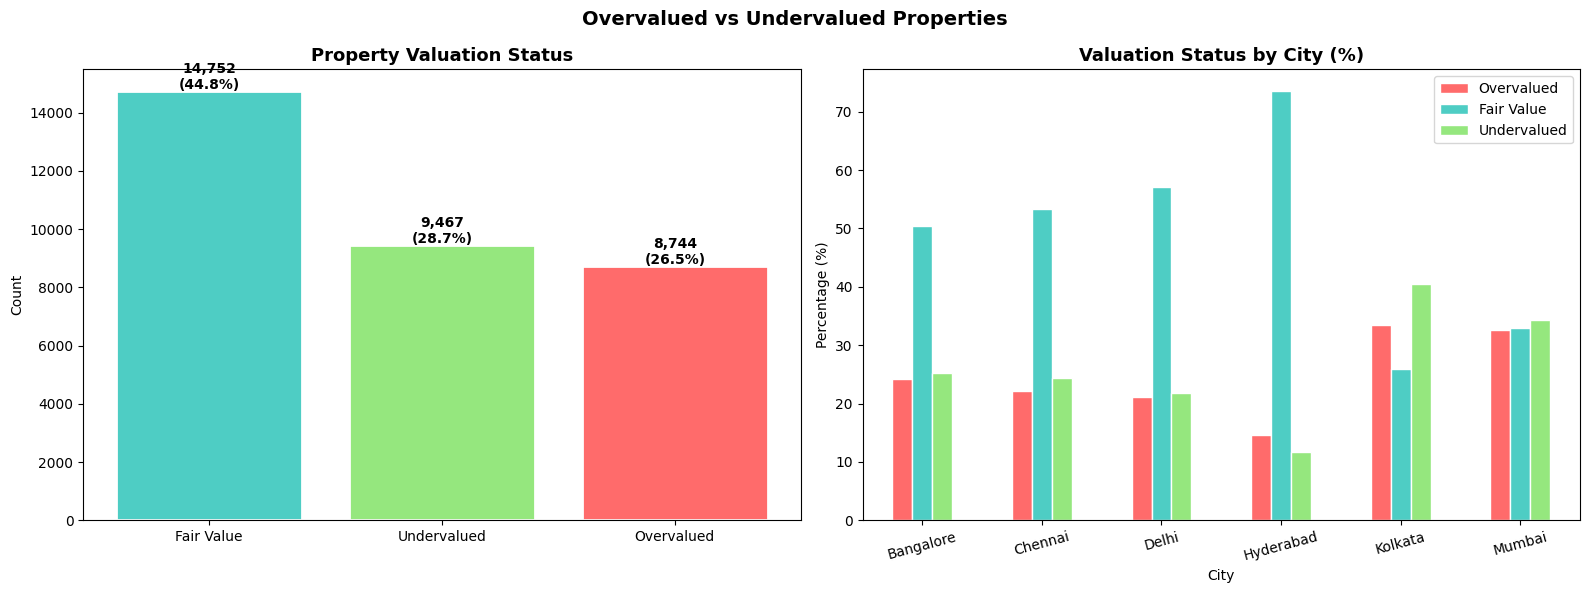

In [32]:
# ── Visualise Overvalued by City ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Valuation status counts
status_counts = df['valuation_status']\
                    .value_counts()
colors = {'Overvalued':'#FF6B6B',
          'Fair Value':'#4ECDC4',
          'Undervalued':'#95E77E'}
bars = axes[0].bar(
    status_counts.index,
    status_counts.values,
    color=[colors[s] for s in status_counts.index],
    edgecolor='white', linewidth=2)

for bar, val in zip(bars, status_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{val:,}\n({val/total*100:.1f}%)',
        ha='center', fontweight='bold')

axes[0].set_title('Property Valuation Status',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Plot 2: Overvalued % by city
city_val = df.groupby(['City','valuation_status'])\
                .size().unstack(fill_value=0)
city_val_pct = city_val.div(
    city_val.sum(axis=1), axis=0) * 100

city_val_pct[['Overvalued',
               'Fair Value',
               'Undervalued']].plot(
    kind='bar', ax=axes[1],
    color=['#FF6B6B','#4ECDC4','#95E77E'],
    edgecolor='white')

axes[1].set_title('Valuation Status by City (%)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right')

plt.suptitle('Overvalued vs Undervalued Properties',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_06_valuation_status.png',
            dpi=150, bbox_inches='tight')
plt.show()

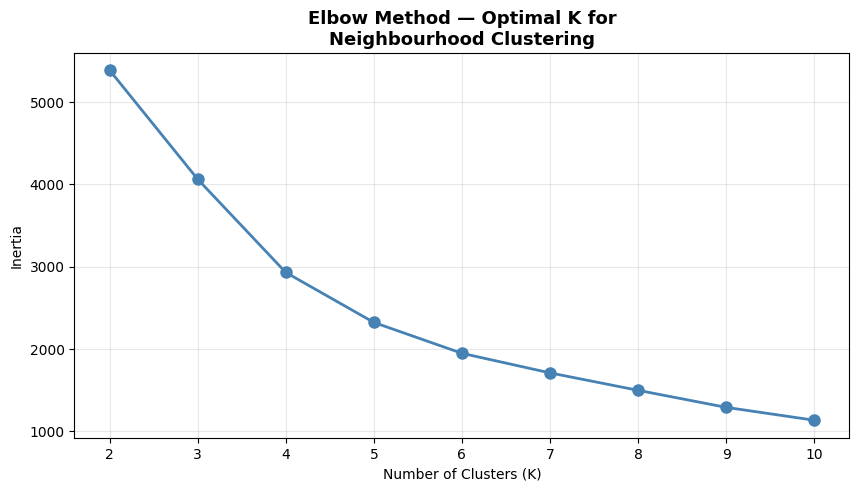

Look at the chart — choose K where the
curve bends most sharply (the 'elbow')
Typically K=4 or K=5 works well


In [36]:
# ============================================
# Step 9: Neighbourhood Clustering (KMeans)
# ============================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate by location
cluster_features_list = ['Price',
                          'Area', 'No. of Bedrooms',
                          'total_amenity_score',
                          'luxury_score']

location_stats = df.groupby('Location')[
    cluster_features_list].median().reset_index()

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(
    location_stats.drop('Location', axis=1))

# Find optimal K using elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k,
                random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o',
         color='steelblue', linewidth=2,
         markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for\n'
          'Neighbourhood Clustering',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('outputs/ML_07_elbow_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Look at the chart — choose K where the")
print("curve bends most sharply (the 'elbow')")
print("Typically K=4 or K=5 works well")

In [37]:
# ── Apply final clustering ─────────────────
# Change K based on your elbow chart
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K,
                  random_state=42, n_init=10)
location_stats['Cluster'] = km_final.fit_predict(scaled)

# Label clusters meaningfully
cluster_profiles = location_stats.groupby('Cluster')[
    cluster_features_list].mean().round(0)
print("\nCLUSTER PROFILES:")
print(cluster_profiles.to_string())

# Name clusters based on profile
# Adjust these names based on what you see
cluster_names = {
    0: 'Budget',
    1: 'Mid-Segment',
    2: 'Premium',
    3: 'Luxury',
    4: 'Ultra-Luxury'
}
location_stats['Cluster_Name'] = \
    location_stats['Cluster'].map(cluster_names)

print("\n✅ Clustering complete!")
print(location_stats['Cluster_Name'].value_counts())


CLUSTER PROFILES:
               Price    Area  No. of Bedrooms  total_amenity_score  luxury_score
Cluster                                                                         
0          9588291.0  1219.0              2.0                  8.0           1.0
1         12734523.0  1525.0              3.0                311.0          27.0
2         10977122.0   916.0              2.0                312.0          27.0
3        384970000.0  2072.0              3.0                315.0          27.0
4         29724925.0  3872.0              4.0                254.0          22.0

✅ Clustering complete!
Cluster_Name
Premium         653
Budget          535
Mid-Segment     511
Ultra-Luxury     67
Luxury           10
Name: count, dtype: int64


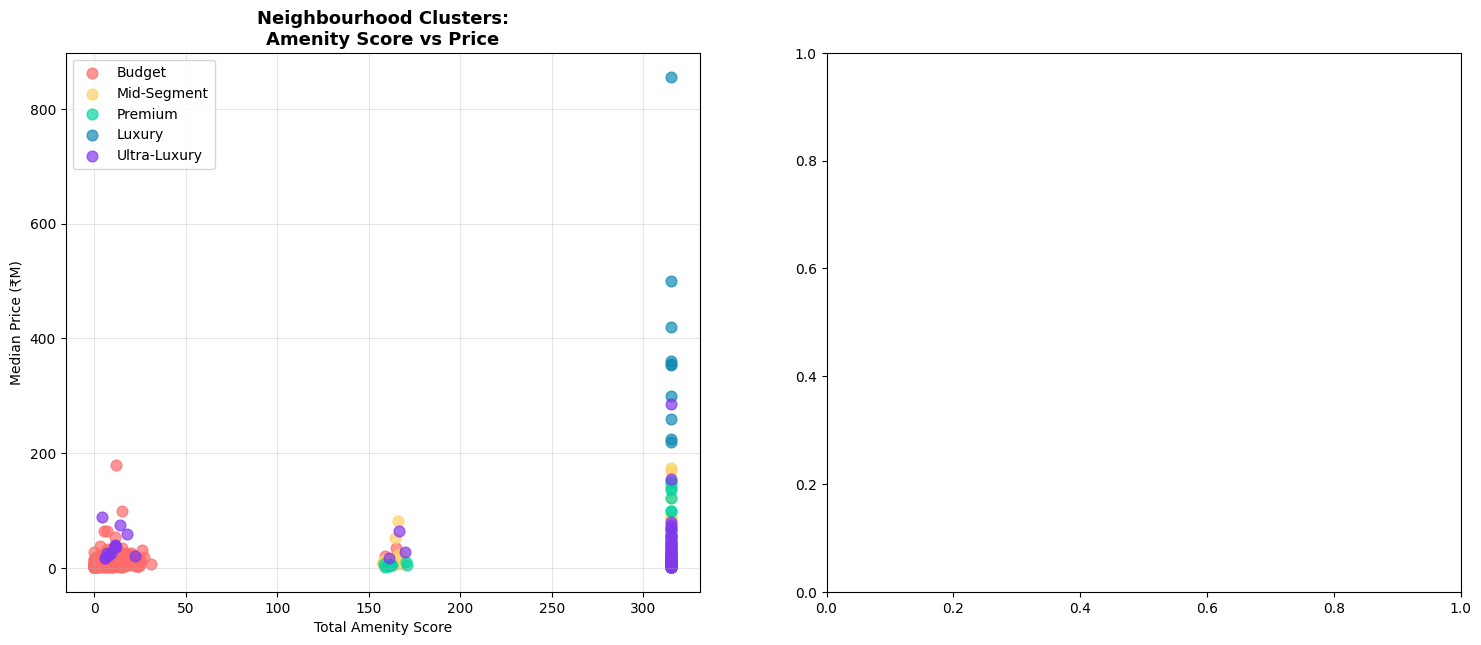

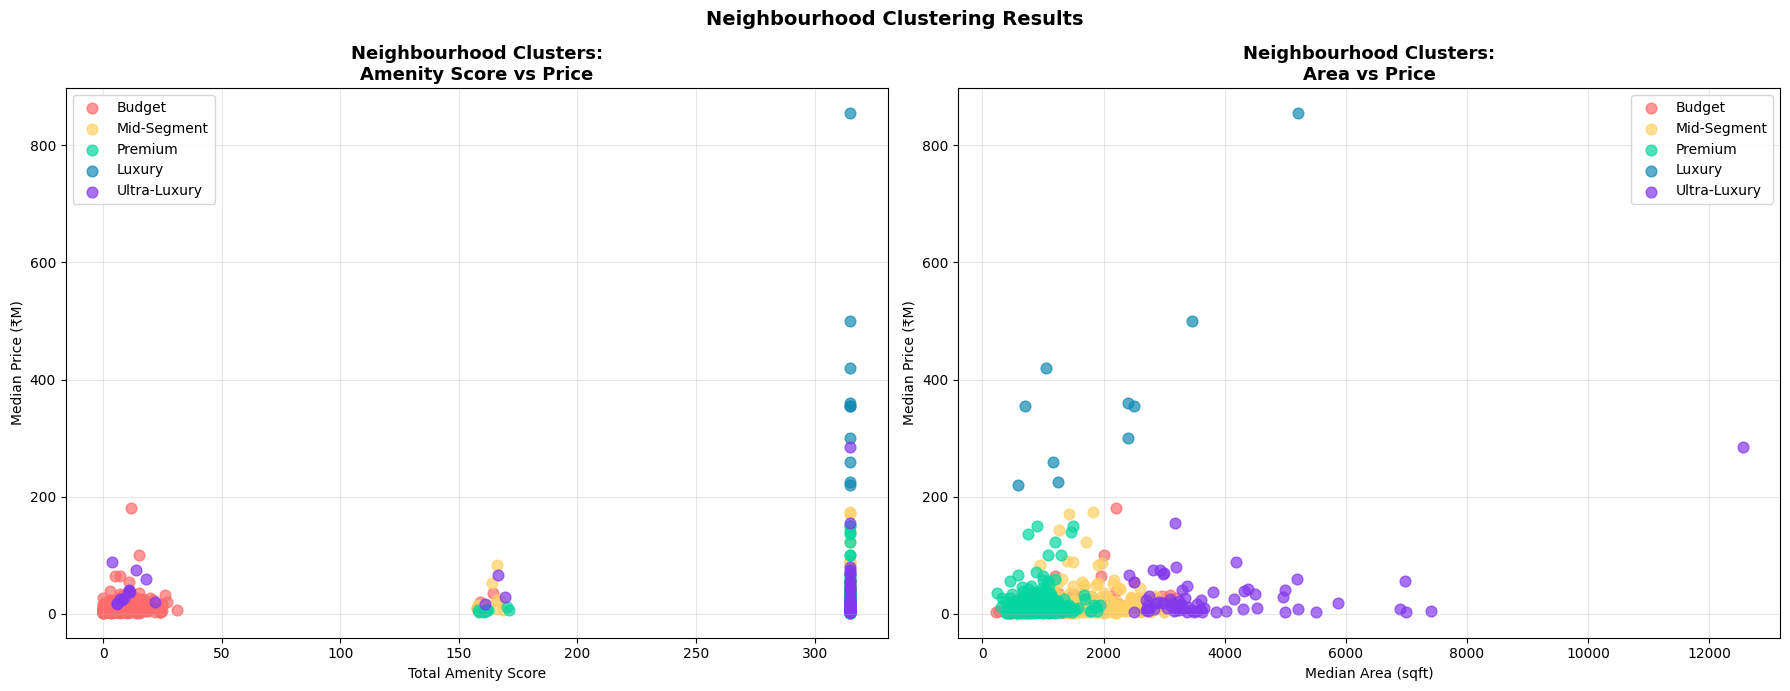

In [39]:
# ── Visualise Clusters ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cluster_colors = ['#FF6B6B','#FFD166',
                   '#06D6A0','#118AB2','#8338EC']

# Plot 1: Price vs Amenity Score by cluster
for cluster_id in range(OPTIMAL_K):
    mask = location_stats['Cluster'] == cluster_id
    axes[0].scatter(
        location_stats[mask]['total_amenity_score'],
        location_stats[mask]['Price']/1e6,
        label=cluster_names.get(cluster_id,
                                 f'Cluster {cluster_id}'),
        color=cluster_colors[cluster_id],
        alpha=0.7, s=60)

axes[0].set_xlabel('Total Amenity Score')
axes[0].set_ylabel('Median Price (₹M)')
axes[0].set_title('Neighbourhood Clusters:\n'
                   'Amenity Score vs Price',
                   fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Price vs Area by cluster
for cluster_id in range(OPTIMAL_K):
    mask = location_stats['Cluster'] == cluster_id
    axes[1].scatter(
        location_stats[mask]['Area'],
        location_stats[mask]['Price']/1e6,
        label=cluster_names.get(cluster_id,
                                 f'Cluster {cluster_id}'),
        color=cluster_colors[cluster_id],
        alpha=0.7, s=60)

axes[1].set_xlabel('Median Area (sqft)')
axes[1].set_ylabel('Median Price (₹M)')
axes[1].set_title('Neighbourhood Clusters:\n'
                   'Area vs Price',
                   fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neighbourhood Clustering Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ML_08_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ============================================
# Step 10: Save all results
# ============================================

import pickle

# Save best model
with open('outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save encoders
with open('outputs/le_city.pkl', 'wb') as f:
    pickle.dump(city, f)

with open('outputs/le_loc.pkl', 'wb') as f:
    pickle.dump(loc, f)

# Save valuation results
df.to_csv('outputs/data_with_predictions.csv',
             index=False)

# Save cluster results
location_stats.to_csv(
    'outputs/neighbourhood_clusters.csv',
    index=False)

print("✅ ALL FILES SAVED:")
files = [
    'outputs/xgb_model.pkl',
    'outputs/le_city.pkl',
    'outputs/le_loc.pkl',
    'outputs/data_with_predictions.csv',
    'outputs/neighbourhood_clusters.csv',
    'outputs/ML_01_actual_vs_predicted.png',
    'outputs/ML_02_error_distribution.png',
    'outputs/ML_03_shap_importance.png',
    'outputs/ML_04_shap_beeswarm.png',
    'outputs/ML_05_shap_waterfall.png',
    'outputs/ML_06_valuation_status.png',
    'outputs/ML_07_elbow_curve.png',
    'outputs/ML_08_clusters.png',
]
for f in files:
    print(f"   {f}")

print("\n🎉 PHASE 3 COMPLETE!")
print("="*40)
print("SUMMARY:")
print(f"  Models trained:     3")
print(f"  Properties scored:  {len(df):,}")
print(f"  Charts generated:   8")
print(f"  SHAP plots:         3")
print()
print("✅ Ready for Phase 4 — Geospatial Maps")

✅ ALL FILES SAVED:
   outputs/xgb_model.pkl
   outputs/le_city.pkl
   outputs/le_loc.pkl
   outputs/data_with_predictions.csv
   outputs/neighbourhood_clusters.csv
   outputs/ML_01_actual_vs_predicted.png
   outputs/ML_02_error_distribution.png
   outputs/ML_03_shap_importance.png
   outputs/ML_04_shap_beeswarm.png
   outputs/ML_05_shap_waterfall.png
   outputs/ML_06_valuation_status.png
   outputs/ML_07_elbow_curve.png
   outputs/ML_08_clusters.png

🎉 PHASE 3 COMPLETE!
SUMMARY:
  Models trained:     3
  Properties scored:  32,963
  Charts generated:   8
  SHAP plots:         3

✅ Ready for Phase 4 — Geospatial Maps


In [44]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# Run this cell first
# ============================================

!pip install folium geopy -q

print("✅ Libraries installed!")

✅ Libraries installed!


In [45]:
# ============================================
# PHASE 4: GEOSPATIAL MAPS
# Real Estate Price Intelligence Platform
# ============================================

import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Load data with predictions from Phase 3
df = pd.read_csv('outputs/data_with_predictions.csv')
clusters = pd.read_csv(
    'outputs/neighbourhood_clusters.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"   Cities: {df['City'].nunique()}")
print(f"   Locations: {df['Location'].nunique()}")

✅ Data loaded: (32963, 52)
   Cities: 6
   Locations: 1776


In [46]:
# ============================================
# Step 2: City Coordinates
# Manual entry — faster than API for 6 cities
# ============================================

# Exact coordinates for all 6 cities
CITY_COORDS = {
    'Mumbai':    {'lat': 19.0760, 'lon': 72.8777,
                  'zoom': 11},
    'Bangalore': {'lat': 12.9716, 'lon': 77.5946,
                  'zoom': 11},
    'Kolkata':   {'lat': 22.5726, 'lon': 88.3639,
                  'zoom': 11},
    'Chennai':   {'lat': 13.0827, 'lon': 80.2707,
                  'zoom': 11},
    'Delhi':     {'lat': 28.7041, 'lon': 77.1025,
                  'zoom': 11},
    'Hyderabad': {'lat': 17.3850, 'lon': 78.4867,
                  'zoom': 11},
}

# India center for overview map
INDIA_CENTER = {'lat': 20.5937, 'lon': 78.9629,
                'zoom': 5}

print("✅ City coordinates defined")
for city, coords in CITY_COORDS.items():
    print(f"   {city:<12}: "
          f"({coords['lat']}, {coords['lon']})")

✅ City coordinates defined
   Mumbai      : (19.076, 72.8777)
   Bangalore   : (12.9716, 77.5946)
   Kolkata     : (22.5726, 88.3639)
   Chennai     : (13.0827, 80.2707)
   Delhi       : (28.7041, 77.1025)
   Hyderabad   : (17.385, 78.4867)


In [49]:
# ============================================
# Step 3: Geocode Unique Locations
# This gets lat/lon for each neighbourhood
# ============================================

# Get unique location-city pairs
loc_city = df.groupby(['Location','City'])\
             .agg({'Price': 'median',
                   'price_per_sqft': 'median',
                   'total_amenity_score': 'median',
                   'valuation_status': lambda x:
                       x.value_counts().index[0],
                   'No. of Bedrooms': 'median'})\
             .reset_index()

print(f"Unique locations to geocode: "
      f"{len(loc_city)}")
print("This will take several minutes...")
print("We use rate limiting to avoid API blocks")

Unique locations to geocode: 1790
This will take several minutes...
We use rate limiting to avoid API blocks


In [54]:
# ============================================
# Step 3B: Geocoding with rate limiter
# ============================================

# Check if we already have geocoded data
geocode_file = 'outputs/location_coords.csv'
force_regeocode = False

if os.path.exists(geocode_file):
    print("✅ Loading existing geocoded data...")
    loc_coords = pd.read_csv(geocode_file)
    print(f"   Loaded {len(loc_coords)} locations")

    # Check if 'price_per_sqft' column exists
    if 'price_per_sqft' not in loc_coords.columns:
        print("⚠️  'price_per_sqft' column missing in loaded file. Forcing re-geocoding...")
        os.remove(geocode_file) # Delete the stale file
        force_regeocode = True
    else:
        print("   'price_per_sqft' column present.")
else:
    force_regeocode = True

if force_regeocode:
    print("Starting geocoding...")
    print("⚠️  This takes several minutes")
    print("    Do NOT interrupt — "
          "progress saves automatically")

    geolocator = Nominatim(
        user_agent="realestate_intel_2026")
    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1.2)

    coords_list = []
    total = len(loc_city)

    for i, row in loc_city.iterrows():
        location_name = (f"{row['Location']}, "
                        f"{row['City']}, India")
        try:
            loc = geocode(location_name)
            if loc:
                coords_list.append({
                    'Location': row['Location'],
                    'City': row['City'],
                    'lat': loc.latitude,
                    'lon': loc.longitude,
                    'Price': row['Price'],
                    'price_per_sqft':
                        row['price_per_sqft'],
                    'total_amenity_score':
                        row['total_amenity_score'],
                    'valuation_status':
                        row['valuation_status'],
                    'No. of Bedrooms':
                        row['No. of Bedrooms']
                })
            else:
                # Fallback: use city center
                city = row['City']
                if city in CITY_COORDS:
                    import random
                    offset_lat = random.uniform(
                        -0.05, 0.05)
                    offset_lon = random.uniform(
                        -0.05, 0.05)
                    coords_list.append({
                        'Location': row['Location'],
                        'City': row['City'],
                        'lat': CITY_COORDS[city]['lat']
                               + offset_lat,
                        'lon': CITY_COORDS[city]['lon']
                               + offset_lon,
                        'Price': row['Price'],
                        'price_per_sqft':
                            row['price_per_sqft'],
                        'total_amenity_score':
                            row['total_amenity_score'],
                        'valuation_status':
                            row['valuation_status'],
                        'No. of Bedrooms':
                            row['No. of Bedrooms']
                    })
        except Exception as e:
            # Handle potential errors during geocoding, e.g., network issues
            print(f"   Error geocoding {location_name}: {e}")
            pass # Continue to the next location even if one fails

        # Progress update every 50 locations
        if (i + 1) % 50 == 0:
            print(f"   Progress: "
                  f"{i+1}/{total} locations done")

        # Save progress every 100 locations
        if (i + 1) % 100 == 0:
            temp_df = pd.DataFrame(coords_list)
            temp_df.to_csv(geocode_file, index=False)

    # Final save
    loc_coords = pd.DataFrame(coords_list)
    loc_coords.to_csv(geocode_file, index=False)
    print(f"\n✅ Geocoding complete!")
    print(f"   {len(loc_coords)} locations geocoded")
    print(f"   Saved to: {geocode_file}")

# Ensure loc_coords exists and has price_per_sqft after all operations
if 'loc_coords' not in locals() or 'price_per_sqft' not in loc_coords.columns:
    raise ValueError("loc_coords DataFrame is not correctly formed with 'price_per_sqft'")

✅ Loading existing geocoded data...
   Loaded 1790 locations
   'price_per_sqft' column present.


In [51]:
# ============================================
# MAP 1: India Overview
# Shows all 6 cities with price comparison
# ============================================

m1 = folium.Map(
    location=[INDIA_CENTER['lat'],
              INDIA_CENTER['lon']],
    zoom_start=INDIA_CENTER['zoom'],
    tiles='CartoDB positron'
)

# City price data
city_stats = df.groupby('City').agg({
    'Price': 'median',
    'price_per_sqft': 'median',
    'No. of Bedrooms': lambda x:
        x.mode()[0],
    'total_amenity_score': 'median'
}).reset_index()

# Color scale based on price per sqft
max_psf = city_stats['price_per_sqft'].max()
min_psf = city_stats['price_per_sqft'].min()

def get_color(psf, min_v, max_v):
    norm = (psf - min_v) / (max_v - min_v)
    if norm > 0.75:
        return '#d73027'   # dark red — expensive
    elif norm > 0.5:
        return '#fc8d59'   # orange
    elif norm > 0.25:
        return '#91cf60'   # light green
    else:
        return '#1a9850'   # dark green — affordable

for _, row in city_stats.iterrows():
    city = row['City']
    if city not in CITY_COORDS:
        continue

    lat = CITY_COORDS[city]['lat']
    lon = CITY_COORDS[city]['lon']
    psf = row['price_per_sqft']
    color = get_color(psf, min_psf, max_psf)

    # Circle size proportional to listing count
    city_count = len(df[df['City']==city])
    radius = 20000 + (city_count / 50)

    # Add circle
    folium.CircleMarker(
        location=[lat, lon],
        radius=25,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(f"""
            <div style='font-family:Arial;
                        width:220px'>
            <h3 style='color:#2D5016;
                       margin:0'>{city}</h3>
            <hr style='border-color:#4A7C28'>
            <b>Median Price/sqft:</b>
                ₹{psf:,.0f}<br>
            <b>Total Listings:</b>
                {city_count:,}<br>
            <b>Common BHK:</b>
                {int(row['No. of Bedrooms'])} BHK<br>
            <b>Avg Amenity Score:</b>
                {row['total_amenity_score']:.1f}<br>
            <hr>
            <small style='color:gray'>
            Click city markers for details
            </small>
            </div>
        """, max_width=250),
        tooltip=f"{city}: ₹{psf:,.0f}/sqft"
    ).add_to(m1)

    # City label
    folium.Marker(
        location=[lat + 0.3, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style='font-size:12px;
                        font-weight:bold;
                        color:#2D5016;
                        white-space:nowrap'>
                {city}
            </div>""",
            icon_size=(100, 30),
            icon_anchor=(50, 0)
        )
    ).add_to(m1)

# Legend
legend_html = """
<div style='position:fixed;
     bottom:30px; left:30px;
     z-index:1000;
     background-color:white;
     padding:12px;
     border:2px solid #2D5016;
     border-radius:8px;
     font-family:Arial;
     font-size:12px'>
<b style='color:#2D5016'>Price per Sqft</b><br>
<i style='color:#d73027'>●</i>
    Very High (>₹8,000)<br>
<i style='color:#fc8d59'>●</i>
    High (₹6,000–8,000)<br>
<i style='color:#91cf60'>●</i>
    Moderate (₹4,500–6,000)<br>
<i style='color:#1a9850'>●</i>
    Affordable (<₹4,500)<br>
<hr style='margin:4px 0'>
<small>Click markers for details</small>
</div>
"""
m1.get_root().html.add_child(
    folium.Element(legend_html))

# Title
title_html = """
<div style='position:fixed;
     top:10px; left:50%;
     transform:translateX(-50%);
     z-index:1000;
     background-color:white;
     padding:10px 20px;
     border:2px solid #2D5016;
     border-radius:8px;
     font-family:Arial'>
<h3 style='margin:0;color:#2D5016'>
    🏠 India Real Estate Price Intelligence
</h3>
<p style='margin:2px 0;
          color:#666;font-size:12px'>
    6 Cities | 27,505 Properties
</p>
</div>
"""
m1.get_root().html.add_child(
    folium.Element(title_html))

m1.save('outputs/map1_india_overview.html')
print("✅ Map 1 saved: map1_india_overview.html")

✅ Map 1 saved: map1_india_overview.html


In [52]:
# ============================================
# MAP 2: Price Heatmap per City
# Creates separate heatmap for each city
# ============================================

def create_city_heatmap(city_name, df_city,
                         loc_coords_city):

    city_info = CITY_COORDS[city_name]
    m = folium.Map(
        location=[city_info['lat'],
                  city_info['lon']],
        zoom_start=city_info['zoom'],
        tiles='CartoDB positron'
    )

    # Prepare heat data
    heat_data = []
    for _, row in loc_coords_city.iterrows():
        if pd.notna(row['lat']) and \
           pd.notna(row['lon']):
            heat_data.append([
                row['lat'],
                row['lon'],
                row['price_per_sqft']
            ])

    if heat_data:
        HeatMap(
            heat_data,
            name=f'{city_name} Price Heatmap',
            min_opacity=0.4,
            radius=20,
            blur=15,
            gradient={
                0.2: '#1a9850',
                0.4: '#91cf60',
                0.6: '#fee08b',
                0.8: '#fc8d59',
                1.0: '#d73027'
            }
        ).add_to(m)

    # City stats box
    med_price = df_city['Price'].median()
    med_psf = df_city['price_per_sqft'].median()
    total_props = len(df_city)

    stats_html = f"""
    <div style='position:fixed;
         top:10px; right:10px;
         z-index:1000;
         background:white;
         padding:12px;
         border:2px solid #2D5016;
         border-radius:8px;
         font-family:Arial;
         min-width:180px'>
    <h3 style='margin:0;color:#2D5016'>
        {city_name}
    </h3>
    <hr style='border-color:#4A7C28;margin:6px 0'>
    <b>Median Price:</b>
        ₹{med_price/1e6:.2f}M<br>
    <b>Price/sqft:</b>
        ₹{med_psf:,.0f}<br>
    <b>Properties:</b>
        {total_props:,}<br>
    <hr style='margin:6px 0'>
    <small style='color:#888'>
    🔴 Expensive | 🟢 Affordable
    </small>
    </div>
    """
    m.get_root().html.add_child(
        folium.Element(stats_html))

    # Layer control
    folium.LayerControl().add_to(m)

    filename = (f'outputs/map2_{city_name.lower()}'
                f'_heatmap.html')
    m.save(filename)
    print(f"   ✅ {city_name} heatmap saved")
    return m


print("Creating city-wise price heatmaps...")
for city in CITY_COORDS.keys():
    df_city = df[df['City']==city]
    loc_city_data = loc_coords[
        loc_coords['City']==city]
    create_city_heatmap(city, df_city,
                        loc_city_data)

print("✅ All city heatmaps created!")

Creating city-wise price heatmaps...
   ✅ Mumbai heatmap saved
   ✅ Bangalore heatmap saved
   ✅ Kolkata heatmap saved
   ✅ Chennai heatmap saved
   ✅ Delhi heatmap saved
   ✅ Hyderabad heatmap saved
✅ All city heatmaps created!


In [57]:
# ============================================
# MAP 3: Overvalued vs Undervalued Properties
# ============================================

def create_valuation_map(city_name):

    city_info = CITY_COORDS[city_name]
    m = folium.Map(
        location=[city_info['lat'],
                  city_info['lon']],
        zoom_start=city_info['zoom'],
        tiles='CartoDB positron'
    )

    # Merge valuation data with coordinates
    city_locs = loc_coords[
        loc_coords['City']==city_name].copy()

    # Merge with valuation status
    val_data = df[df['City']==city_name]\
        .groupby('Location').agg({
            'valuation_status': lambda x:
                x.value_counts().index[0],
            'price_deviation_%': 'median',
            'Price': 'median',
            'predicted_price': 'median',
            'price_per_sqft': 'median'
        }).reset_index()

    city_locs = city_locs.merge(
        val_data, on='Location', how='left')

    # Color coding
    status_colors = {
        'Overvalued':  '#FF4444',
        'Fair Value':  '#44AA44',
        'Undervalued': '#4444FF'
    }

    # Create feature groups for toggling
    overvalued_group = folium.FeatureGroup(
        name='🔴 Overvalued')
    fair_group = folium.FeatureGroup(
        name='🟢 Fair Value')
    undervalued_group = folium.FeatureGroup(
        name='🔵 Undervalued')

    group_map = {
        'Overvalued': overvalued_group,
        'Fair Value': fair_group,
        'Undervalued': undervalued_group
    }

    for _, row in city_locs.iterrows():
        if pd.isna(row['lat']) or \
           pd.isna(row['lon']):
            continue

        # Use _y suffix for merged columns from val_data
        status = row.get('valuation_status_y', 'Fair Value') # Use _y for merged valuation status
        if pd.isna(status):
            status = 'Fair Value'

        color = status_colors.get(
            status, '#44AA44')
        dev = row.get('price_deviation_%', 0)
        actual = row.get('Price_y', 0) # Use _y for merged Price
        predicted = row.get('predicted_price', 0)

        popup_html = f"""
        <div style='font-family:Arial;
                    width:230px'>
        <h4 style='margin:0;
                   color:{color}'>
            {status}
        </h4>
        <b>{row['Location']}</b><br>
        <hr style='margin:4px 0'>
        <b>Actual Price:</b>
            ₹{actual/1e5:.1f}L<br>
        <b>Predicted:</b>
            ₹{predicted/1e5:.1f}L<br>
        <b>Deviation:</b>
            {dev:+.1f}%<br>
        <b>Price/sqft:</b>
            ₹{row['price_per_sqft_y']:,.0f}<br> # Use _y for merged price_per_sqft
        <hr style='margin:4px 0'>
        <small style='color:#666'>
        {'⚠️ Seller asking too much'
          if status=='Overvalued'
          else '✅ Good deal — below market'
          if status=='Undervalued'
          else '✅ Fairly priced'}
        </small>
        </div>
        """

        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(
                popup_html, max_width=250),
            tooltip=(f"{row['Location']}: "
                     f"{status} ({dev:+.1f}%)")
        ).add_to(group_map[status])

    # Add groups to map
    for group in group_map.values():
        group.add_to(m)

    # Layer control
    folium.LayerControl().add_to(m)

    # Legend
    legend_html = """
    <div style='position:fixed;
         bottom:30px;left:30px;
         z-index:1000;
         background:white;
         padding:12px;
         border:2px solid #2D5016;
         border-radius:8px;
         font-family:Arial;
         font-size:12px'>
    <b style='color:#2D5016'>
        Valuation Status
    </b><br>
    <i style='color:#FF4444'>●</i>
        Overvalued (>20% above model)<br>
    <i style='color:#44AA44'>●</i>
        Fair Value (±20%)<br>
    <i style='color:#4444FF'>●</i>
        Undervalued (>20% below model)<br>
    <hr style='margin:4px 0'>
    <small>Toggle layers using control ↗</small>
    </div>
    """
    m.get_root().html.add_child(
        folium.Element(legend_html))

    filename = (f'outputs/map3_{city_name.lower()}'
                f'_valuation.html')
    m.save(filename)
    print(f"   ✅ {city_name} valuation map saved")


print("Creating valuation maps...")
for city in CITY_COORDS.keys():
    create_valuation_map(city)

print("✅ All valuation maps created!")

Creating valuation maps...
   ✅ Mumbai valuation map saved
   ✅ Bangalore valuation map saved
   ✅ Kolkata valuation map saved
   ✅ Chennai valuation map saved
   ✅ Delhi valuation map saved
   ✅ Hyderabad valuation map saved
✅ All valuation maps created!


In [58]:
# ============================================
# MAP 4: Neighbourhood Cluster Map
# Shows which localities belong to which
# market segment (Budget/Mid/Premium/Luxury)
# ============================================

cluster_colors_map = {
    'Budget':       '#1a9850',
    'Mid-Segment':  '#fee08b',
    'Premium':      '#fc8d59',
    'Luxury':       '#d73027',
    'Ultra-Luxury': '#7b2d8b'
}

# Default if cluster names differ
default_colors = ['#1a9850','#fee08b',
                   '#fc8d59','#d73027','#7b2d8b']

def create_cluster_map(city_name):

    city_info = CITY_COORDS[city_name]
    m = folium.Map(
        location=[city_info['lat'],
                  city_info['lon']],
        zoom_start=city_info['zoom'],
        tiles='CartoDB positron'
    )

    # Merge cluster data with coords
    city_locs = loc_coords[
        loc_coords['City']==city_name].copy()

    city_clusters = clusters[
        clusters['City']==city_name][
        ['Location','Cluster',
         'Cluster_Name']].copy() \
        if 'City' in clusters.columns \
        else clusters[
        ['Location','Cluster',
         'Cluster_Name']].copy()

    city_locs = city_locs.merge(
        city_clusters, on='Location', how='left')

    unique_clusters = city_locs['Cluster_Name']\
        .dropna().unique()

    # Feature groups per cluster
    cluster_groups = {}
    for cn in unique_clusters:
        color = cluster_colors_map.get(
            cn, default_colors[0])
        cluster_groups[cn] = folium.FeatureGroup(
            name=f'Segment: {cn}')

    for _, row in city_locs.iterrows():
        if pd.isna(row['lat']) or \
           pd.isna(row['lon']):
            continue

        cluster_name = row.get('Cluster_Name',
                                'Unknown')
        if pd.isna(cluster_name):
            continue

        color = cluster_colors_map.get(
            cluster_name, '#888888')

        popup_html = f"""
        <div style='font-family:Arial;
                    width:200px'>
        <b style='color:{color}'>
            {cluster_name} Segment
        </b><br>
        <b>Location:</b>
            {row['Location']}<br>
        <b>Median Price:</b>
            ₹{row['Price']/1e5:.1f}L<br>
        <b>Price/sqft:</b>
            ₹{row['price_per_sqft']:,.0f}<br>
        <b>Amenity Score:</b>
            {row['total_amenity_score']:.1f}
        </div>
        """

        if cluster_name in cluster_groups:
            folium.CircleMarker(
                location=[row['lat'],
                           row['lon']],
                radius=9,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.75,
                popup=folium.Popup(
                    popup_html,
                    max_width=220),
                tooltip=(f"{row['Location']}: "
                         f"{cluster_name}")
            ).add_to(cluster_groups[cluster_name])

    for group in cluster_groups.values():
        group.add_to(m)

    folium.LayerControl().add_to(m)

    # Legend
    legend_items = ''.join([
        f"<i style='color:{v}'>●</i> {k}<br>"
        for k, v in cluster_colors_map.items()
    ])
    legend_html = f"""
    <div style='position:fixed;
         bottom:30px;left:30px;
         z-index:1000;
         background:white;
         padding:12px;
         border:2px solid #2D5016;
         border-radius:8px;
         font-family:Arial;
         font-size:12px'>
    <b style='color:#2D5016'>
        Market Segments
    </b><br>
    {legend_items}
    <hr style='margin:4px 0'>
    <small>Toggle layers using control ↗</small>
    </div>
    """
    m.get_root().html.add_child(
        folium.Element(legend_html))

    filename = (f'outputs/map4_{city_name.lower()}'
                f'_clusters.html')
    m.save(filename)
    print(f"   ✅ {city_name} cluster map saved")


print("Creating cluster maps...")
for city in CITY_COORDS.keys():
    create_cluster_map(city)

print("✅ All cluster maps created!")

Creating cluster maps...
   ✅ Mumbai cluster map saved
   ✅ Bangalore cluster map saved
   ✅ Kolkata cluster map saved
   ✅ Chennai cluster map saved
   ✅ Delhi cluster map saved
   ✅ Hyderabad cluster map saved
✅ All cluster maps created!


In [60]:
# ============================================
# MAP 5: Master Combined Map
# All layers in one interactive map
# (Best map for portfolio/dashboard)
# ============================================

def create_master_map(city_name):

    city_info = CITY_COORDS[city_name]
    m = folium.Map(
        location=[city_info['lat'],
                  city_info['lon']],
        zoom_start=city_info['zoom'],
        tiles='CartoDB positron'
    )

    # Add multiple tile layers
    folium.TileLayer(
        'OpenStreetMap',
        name='Street Map').add_to(m)
    folium.TileLayer(
        'CartoDB dark_matter',
        name='Dark Mode').add_to(m)

    city_locs = loc_coords[
        loc_coords['City']==city_name].copy()

    # Merge all data
    val_data = df[df['City']==city_name]\
        .groupby('Location').agg({
            'valuation_status': lambda x:
                x.value_counts().index[0],
            'price_deviation_%': 'median',
            'Price': 'median',
            'predicted_price': 'median',
            'price_per_sqft': 'median',
            'total_amenity_score': 'median',
            'No. of Bedrooms': lambda x:
                x.mode()[0]
        }).reset_index()

    city_locs = city_locs.merge(
        val_data, on='Location', how='left')

    # --- LAYER 1: Price Heatmap ---
    heat_group = folium.FeatureGroup(
        name='🌡️ Price Heatmap')
    heat_data = [
        [row['lat'], row['lon'],
         row['price_per_sqft_y']] # Use _y suffix
        for _, row in city_locs.iterrows()
        if pd.notna(row['lat'])
        and pd.notna(row['price_per_sqft_y']) # Use _y suffix
    ]
    if heat_data:
        HeatMap(
            heat_data,
            radius=18, blur=12,
            gradient={
                0.2: '#1a9850',
                0.5: '#fee08b',
                0.8: '#fc8d59',
                1.0: '#d73027'
            }
        ).add_to(heat_group)
    heat_group.add_to(m)

    # --- LAYER 2: Property Markers ---
    markers_group = folium.FeatureGroup(
        name='📍 Property Locations')
    cluster = MarkerCluster().add_to(
        markers_group)

    val_colors = {
        'Overvalued': 'red',
        'Fair Value': 'green',
        'Undervalued': 'blue'
    }

    for _, row in city_locs.iterrows():
        if pd.isna(row['lat']) or \
           pd.isna(row['lon']):
            continue

        status = row.get('valuation_status_y', # Use _y suffix
                         'Fair Value')
        if pd.isna(status):
            status = 'Fair Value'

        color = val_colors.get(status, 'green')
        dev = row.get('price_deviation_%', 0)
        if pd.isna(dev):
            dev = 0

        popup_content = f"""
        <div style='font-family:Arial;
                    min-width:220px'>
        <h4 style='color:#2D5016;margin:0'>
            {row['Location']}
        </h4>
        <hr style='margin:4px 0'>
        <table style='font-size:12px;
                      width:100%'>
        <tr>
            <td><b>Price:</b></td>
            <td>₹{row['Price_y']/1e5:.1f}L</td> # Use _y suffix
        </tr>
        <tr>
            <td><b>₹/sqft:</b></td>
            <td>₹{row['price_per_sqft_y']:,.0f}</td> # Use _y suffix
        </tr>
        <tr>
            <td><b>Amenity Score:</b></td>
            <td>{row['total_amenity_score_y']:.1f}</td> # Use _y suffix
        </tr>
        <tr>
            <td><b>Valuation:</b></td>
            <td style='color:{
                "red" if status=="Overvalued"
                else "blue" if status=="Undervalued"
                else "green"}'>
                <b>{status}</b>
                ({dev:+.1f}%)
            </td>
        </tr>
        </table>
        <hr style='margin:4px 0'>
        <small style='color:#888'>
        Common: {int(row['No. of Bedrooms_y'])} BHK # Use _y suffix
        </small>
        </div>
        """

        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=folium.Popup(
                popup_content, max_width=260),
            tooltip=f"{row['Location']} "
                    f"| ₹{row['price_per_sqft_y']:,.0f}/sqft" # Use _y suffix
                    f" | {status}",
            icon=folium.Icon(
                color=color,
                icon='home',
                prefix='fa')
        ).add_to(cluster)

    markers_group.add_to(m)

    # Layer control
    folium.LayerControl(collapsed=False).add_to(m)

    # Stats panel
    city_df = df[df['City']==city_name]
    overval_pct = (
        city_df['valuation_status']=='Overvalued'
    ).mean() * 100
    underval_pct = (
        city_df['valuation_status']=='Undervalued'
    ).mean() * 100

    stats_html = f"""
    <div style='position:fixed;
         top:10px;right:10px;
         z-index:1000;
         background:white;
         padding:14px;
         border:2px solid #2D5016;
         border-radius:10px;
         font-family:Arial;
         min-width:200px;
         box-shadow:2px 2px 6px rgba(0,0,0,0.2)'>
    <h3 style='margin:0;color:#2D5016'>
        🏠 {city_name}
    </h3>
    <p style='margin:2px 0;color:#666;
              font-size:11px'>
        Real Estate Intelligence
    </p>
    <hr style='border-color:#4A7C28;margin:6px 0'>
    <b>Listings:</b>
        {len(city_df):,}<br>
    <b>Median Price:</b>
        ₹{city_df['Price'].median()/1e6:.2f}M<br>
    <b>Price/sqft:</b>
        ₹{city_df['price_per_sqft'].median():,.0f}<br>
    <hr style='margin:6px 0'>
    <span style='color:red'>●</span>
        Overvalued: {overval_pct:.1f}%<br>
    <span style='color:green'>●</span>
        Fair Value:
        {100-overval_pct-underval_pct:.1f}%<br>
    <span style='color:blue'>●</span>
        Undervalued: {underval_pct:.1f}%
    </div>
    """
    m.get_root().html.add_child(
        folium.Element(stats_html))

    filename = (f'outputs/map5_{city_name.lower()}'
                f'_master.html')
    m.save(filename)
    print(f"   ✅ {city_name} master map saved")


print("Creating master maps (best maps)...")
for city in CITY_COORDS.keys():
    create_master_map(city)

print("✅ All master maps created!")

Creating master maps (best maps)...
   ✅ Mumbai master map saved
   ✅ Bangalore master map saved
   ✅ Kolkata master map saved
   ✅ Chennai master map saved
   ✅ Delhi master map saved
   ✅ Hyderabad master map saved
✅ All master maps created!


In [61]:
# ============================================
# Step 9: Phase 4 Complete Summary
# ============================================

import os

map_files = [f for f in os.listdir('outputs/')
             if f.endswith('.html')]
map_files.sort()

print("🎉 PHASE 4 — GEOSPATIAL MAPS COMPLETE!")
print("="*50)
print(f"\n📍 MAPS GENERATED: {len(map_files)}")
print()

map_descriptions = {
    'map1_india_overview.html':
        'India Overview — All 6 cities',
    'map2_':
        'Price Heatmap — per city',
    'map3_':
        'Valuation Map — Overvalued/Undervalued',
    'map4_':
        'Cluster Map — Market Segments',
    'map5_':
        'Master Map — All Layers Combined',
}

for f in map_files:
    size = os.path.getsize(f'outputs/{f}')
    print(f"   📄 {f}")
    print(f"      Size: {size/1024:.0f} KB")

print()
print("HOW TO VIEW MAPS:")
print("  Option 1: Download from Colab")
print("            Files → outputs → "
      "right-click → download")
print("  Option 2: Open in Colab directly")
print("            Run the cell below")

print()
print("NEXT STEP → Phase 5: Streamlit Dashboard")
print("  All maps will be embedded in the")
print("  dashboard automatically")

🎉 PHASE 4 — GEOSPATIAL MAPS COMPLETE!

📍 MAPS GENERATED: 25

   📄 map1_india_overview.html
      Size: 20 KB
   📄 map2_bangalore_heatmap.html
      Size: 19 KB
   📄 map2_chennai_heatmap.html
      Size: 14 KB
   📄 map2_delhi_heatmap.html
      Size: 20 KB
   📄 map2_hyderabad_heatmap.html
      Size: 16 KB
   📄 map2_kolkata_heatmap.html
      Size: 20 KB
   📄 map2_mumbai_heatmap.html
      Size: 25 KB
   📄 map3_bangalore_valuation.html
      Size: 567 KB
   📄 map3_chennai_valuation.html
      Size: 348 KB
   📄 map3_delhi_valuation.html
      Size: 636 KB
   📄 map3_hyderabad_valuation.html
      Size: 456 KB
   📄 map3_kolkata_valuation.html
      Size: 578 KB
   📄 map3_mumbai_valuation.html
      Size: 773 KB
   📄 map4_bangalore_clusters.html
      Size: 494 KB
   📄 map4_chennai_clusters.html
      Size: 303 KB
   📄 map4_delhi_clusters.html
      Size: 554 KB
   📄 map4_hyderabad_clusters.html
      Size: 396 KB
   📄 map4_kolkata_clusters.html
      Size: 503 KB
   📄 map4_mumbai_clusters.

In [62]:
import zipfile
import os

zip_filename = 'maps_output.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in os.listdir('/content'):
        if file.endswith('.html'):
            zipf.write(file)

print("✅ All maps zipped successfully")

✅ All maps zipped successfully


In [63]:
from google.colab import files
files.download('maps_output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.html'):
            print(os.path.join(root, file))

/content/outputs/map4_chennai_clusters.html
/content/outputs/map3_delhi_valuation.html
/content/outputs/map2_mumbai_heatmap.html
/content/outputs/map5_chennai_master.html
/content/outputs/map3_hyderabad_valuation.html
/content/outputs/map5_mumbai_master.html
/content/outputs/map4_hyderabad_clusters.html
/content/outputs/map5_hyderabad_master.html
/content/outputs/map2_kolkata_heatmap.html
/content/outputs/map5_bangalore_master.html
/content/outputs/map4_bangalore_clusters.html
/content/outputs/map1_india_overview.html
/content/outputs/map4_kolkata_clusters.html
/content/outputs/map3_kolkata_valuation.html
/content/outputs/map5_kolkata_master.html
/content/outputs/map5_delhi_master.html
/content/outputs/map2_bangalore_heatmap.html
/content/outputs/map2_hyderabad_heatmap.html
/content/outputs/map4_mumbai_clusters.html
/content/outputs/map4_delhi_clusters.html
/content/outputs/map2_chennai_heatmap.html
/content/outputs/map3_mumbai_valuation.html
/content/outputs/map3_chennai_valuation.htm

In [65]:
import zipfile
import os

zip_filename = 'maps_output.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk('/content'):
        for file in files:
            if file.endswith('.html'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, arcname=file)

print("✅ All HTML maps zipped successfully")

✅ All HTML maps zipped successfully


In [66]:
from google.colab import files
files.download('maps_output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful